 Cargando el dataset
                         Diag 01 Principal (cod+des)  \
0            A41.8 - Otras septicemias especificadas   
1               U07.1 - COVID-19, virus identificado   
2  K56.5 - Adherencias [bridas] intestinales con ...   
3  K76.8 - Otras enfermedades especificadas del h...   
4  T81.0 - Hemorragia y hematoma que complican un...   

                        Diag 02 Secundario (cod+des)  \
0     B37.6 - Endocarditis debida a candida (I39.8*)   
1              J12.8 - Neumonía debida a otros virus   
2                              R57.2 - Shock séptico   
3                              K66.1 - Hemoperitoneo   
4  Y83.2 - Operación quirúrgica con anastomosis, ...   

                        Diag 03 Secundario (cod+des)  \
0  I39.8 - Endocarditis, válvula no especificada,...   
1                                     R06.0 - Disnea   
2                        R57.1 - Choque hipovolémico   
3        N18.5 - Enfermedad renal crónica, estadio 5   
4               S31.1 - H

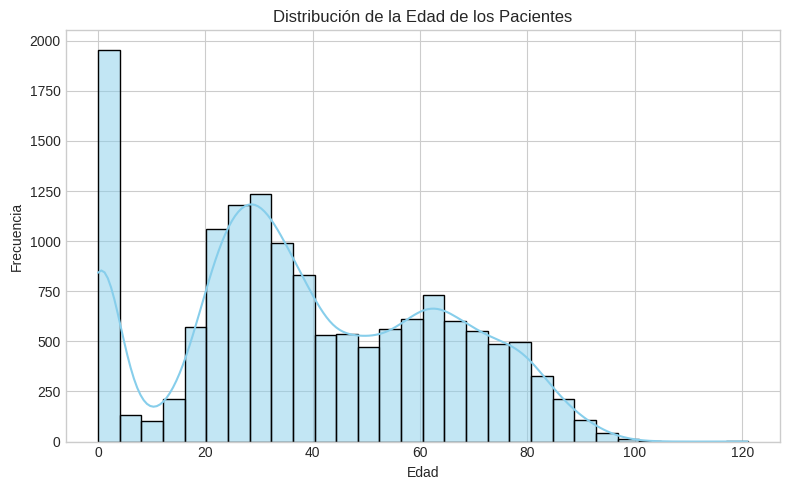

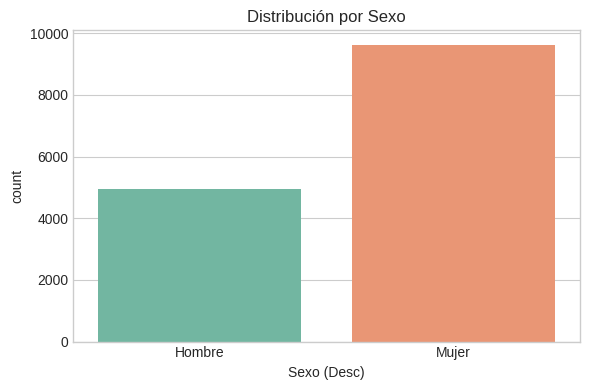

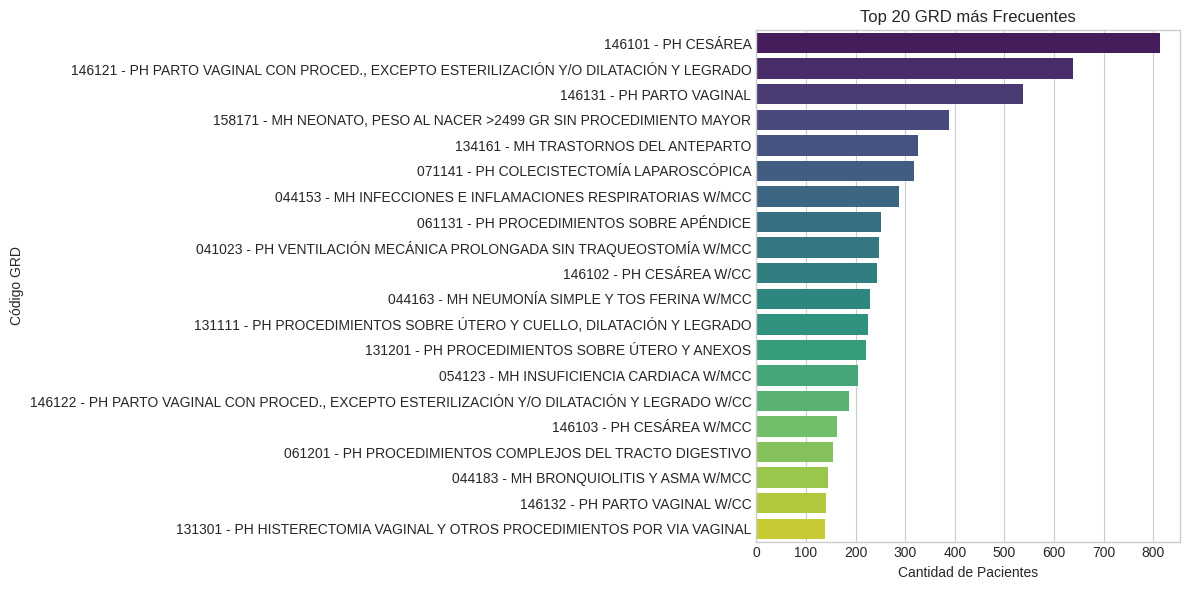


 Preprocesamiento de Datos
Tamaño del set de entrenamiento: (11308, 37)
Tamaño del set de prueba: (2827, 37)

 Entrenando el Modelo

 Evaluación del Modelo
Exactitud (Accuracy) del modelo: 0.4637


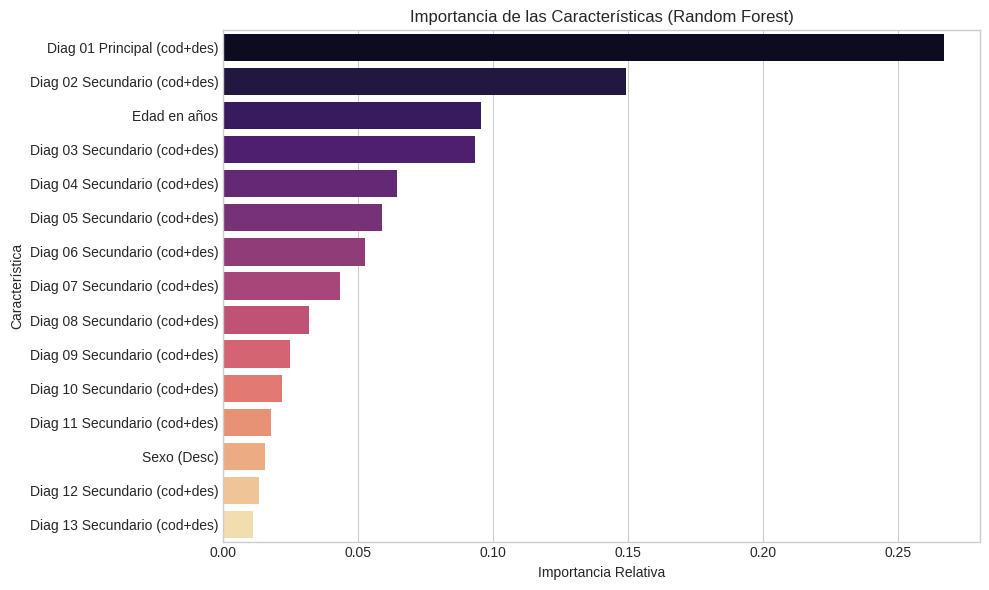

Modelo exportado como random_forest_grd_model.pkl


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(" Cargando el dataset")
df = pd.read_csv('dataset_elpino.csv', sep=';')

print(df.head())
print("\nInformación del dataset:")
print(df.info())

print("\n Análisis Exploratorio de Datos")

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print("Valores nulos por columna:\n", missing_data)

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.values, y=missing_data.index)
    plt.title('Valores Nulos por Atributo')
    plt.xlabel('Cantidad de Nulos')
    plt.ylabel('Atributos')
    plt.tight_layout()
    plt.savefig('nulos_eda.png')
    plt.show()

col_edad = 'Edad' if 'Edad' in df.columns else df.columns[df.columns.str.contains('edad', case=False)][0]
col_grd = 'GRD' if 'GRD' in df.columns else df.columns[df.columns.str.contains('GRD', case=False)][0]
col_sexo = 'Sexo' if 'Sexo' in df.columns else df.columns[df.columns.str.contains('sexo', case=False)][0]

plt.figure(figsize=(8, 5))
sns.histplot(df[col_edad].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribución de la Edad de los Pacientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('distribucion_edad.png')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=col_sexo, palette='Set2')
plt.title('Distribución por Sexo')
plt.tight_layout()
plt.savefig('distribucion_sexo.png')
plt.show()

plt.figure(figsize=(12, 6))
top_grd = df[col_grd].value_counts().head(20)
sns.barplot(x=top_grd.values, y=top_grd.index.astype(str), palette='viridis')
plt.title('Top 20 GRD más Frecuentes')
plt.xlabel('Cantidad de Pacientes')
plt.ylabel('Código GRD')
plt.tight_layout()
plt.savefig('top_grd.png')
plt.show()

print("\n Preprocesamiento de Datos")

min_samples = 5
grd_counts = df[col_grd].value_counts()
valid_grds = grd_counts[grd_counts >= min_samples].index
df_filtered = df[df[col_grd].isin(valid_grds)].copy()

def extract_code(text):
    if pd.isna(text) or text == '-':
        return 'Ninguno'

    return str(text).split('-')[0].strip()

diag_cols = [col for col in df_filtered.columns if 'Diag' in col]

for col in diag_cols:
    df_filtered[col] = df_filtered[col].apply(extract_code)

df_filtered.fillna('Desconocido', inplace=True)

le_dict = {}
categorical_cols = diag_cols + [col_sexo]

for col in categorical_cols:
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))
    le_dict[col] = le

le_target = LabelEncoder()
df_filtered['Target_GRD'] = le_target.fit_transform(df_filtered[col_grd].astype(str))

X = df_filtered[categorical_cols + [col_edad]]
y = df_filtered['Target_GRD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

print("\n Entrenando el Modelo")
clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print("\n Evaluación del Modelo")
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) del modelo: {accuracy:.4f}")

feature_importances = clf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Característica': features, 'Importancia': feature_importances})
importance_df = importance_df.sort_values(by='Importancia', ascending=False).head(15) # Top 15

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=importance_df, palette='magma')
plt.title('Importancia de las Características (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

joblib.dump(clf, 'random_forest_grd_model.pkl')

joblib.dump(le_target, 'label_encoder.pkl')

print("Modelo exportado como random_forest_grd_model.pkl")